## Roughness scaling: predicting $n_e/\langle n\rangle$

_OLS regression on second-order variance components, feature selection (Pearson, mutual information, RF permutation importance), power-law fit of $\langle S_f\rangle$, tracer-flow visual diagnostics, and predicted-vs-observed fits. Extracted from `roughness_scale-decomp.ipynb`._


In [2]:
import warnings
warnings.filterwarnings("ignore")


import os
import os as _os
import sys
import shutil
import itertools as it
import contextlib
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
import json
from scipy.stats import gmean
import pandas as pd

sys.path.append("/Users/octaviacrompton/Projects/roughness-scale/swof_code")


import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

In [3]:
# ── Figure registry (src/figure_registry.py) ──────────────────────────────────
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
import figure_registry as _fig_reg

# Expose convenience names so all figure-saving cells work unchanged
_fig_dirs              = _fig_reg._fig_dirs
update_figure_registry = _fig_reg.update_figure_registry

# Note: call _fig_reg.configure(out_dir) once out_dir is set (see data-load cell)

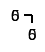

In [4]:
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", 
              "plot_config", "topo", "source_functions_1p3"]

for mod in my_modules:
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *
from source_functions_1p3 import *

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [5]:
project_dir = "/Users/octaviacrompton/Dropbox/FullCSWOF/Tests/"
cases = [d for d in os.listdir(project_dir) if 
            ('DS_Store' not in d) and ('figures' not in d)]


In [6]:

# out_dir must match what was used in roughness_scale-load-compute
out_dir   = os.path.join(project_dir, 'runaround_smooth')
slim_path = os.path.join(out_dir, 'summary_slim.pkl')

summary = pd.read_pickle(slim_path)
summary.loc[summary['veg_type'] == 'band',   'aniso'] =  3
summary.loc[summary['veg_type'] == 'v_band', 'aniso'] = -3
print(f'Loaded summary_slim: shape = {summary.shape}')
print('Columns:', sorted(summary.columns.tolist()))

# initialise figure registry for this session
_fig_reg.configure(out_dir, notebook_name='5. roughness_scale-predict.ipynb')

Loaded summary_slim: shape = (1260, 354)
Columns: ['$p t_r$', '(1+eta)^3/5', '<(h)^3/5>', '<(n q)^3/5>', '<(n)^3/5>', '<(q)^3/5>', '<Sf>', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_T0', '<Sf>_T0_hyb', '<Sf>_T1', '<Sf>_T2', '<Sf>_Ubar2_np2', '<Sf>_cross_nU', '<Sf>_direct', '<Sf>_direct_minus_exp2', '<Sf>_direct_wet', '<Sf>_exp2', '<Sf>_hyb_Up2', '<Sf>_hyb_base', '<Sf>_hyb_cross', '<Sf>_hyb_np2', '<Sf>_hyb_num_sum', '<Sf>_hybrid_quad', '<Sf>_nbar2_Ubar2', '<Sf>_nbar2_Up2', '<Sf>_nd_T0', '<Sf>_nd_T1', '<Sf>_nd_T2', '<Sf>_nd_sumK2', '<Sf>_series2', '<U dU/dx>', '<U>', '<U>/<h>', '<U><dU/dx>', '<U>^2/<Up^2>', '<U>_CF', '<Ua>', '<Uh>', '<Up dUp/dx>', '<Up hp>', '<Up2>', '<dU/dx>', '<dh/dx>', '<dhp/dx>', '<eta ups>', '<eta2>', '<h>', '<h>_CF', '<h^2/3>', '<ha>', '<hp2>', '<n q>', '<n2>', '<n2><h>^-4/3', '<n>', '<n>2', '<n><U>', '<nU>', '<na>', '<np Up>', '<np hp>', '<np2>', '<q>_direct', '<q>_hform', '<q>_uform', '<r eta>', '<r ups>', '<r2>', '<ups2>', 'B_bc_NF', 'B_bc_init', 'Bbound', 'C',

In [7]:
# ── Variable naming / display labels ──────────────────────────────────────────
# Shared labels, colour maps, and helpers live in src/labels.py
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
from labels import (
    updates, rename, renameit,
    VEG_COLORS, VEG_LABELS,
    FS_LABEL, FS_TITLE, FS_TICK, FS_LEG,
    VAR_CMAPS,
    format_name as _format_name_raw,
)

# Wrap format_name so callers don't need to pass `names` explicitly
def format_name(fld, updates=updates):
    return _format_name_raw(fld, names, updates=updates)

summary['LB_std'] = [l.std() for l in summary.LB_dist]

# ── Toggle: set USE_HYDRO = True to make 'effect_ratio' use hydrograph-based n_e
USE_HYDRO = False
if USE_HYDRO:
    summary['effect']       = summary['effect_hydro']
    summary['effect_ratio'] = summary['effect_ratio_hydro']


### OLS regression of $n_e/\langle n\rangle$ on second-order variance components

In [8]:
# --- build table (observed & components) ---
cols = ["effect_ratio", "<r2>", "<eta2>", "<r eta>"]
df = summary.copy()
for c in cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")
dfM = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

y    = dfM["effect_ratio"].to_numpy(float)
x_r2 = dfM["<r2>"].to_numpy(float)
x_e2 = dfM["<eta2>"].to_numpy(float)
x_re = dfM["<r eta>"].to_numpy(float)

from stats import fit_ols, eval_yhat

results = []

# ----- Full model: effect_ratio ~ 1 + <r2> + <eta2> + <r eta> -----
X_full = np.column_stack([np.ones_like(y), x_r2, x_e2, x_re])
b, r2_full, adj_full, yhat_full = fit_ols(X_full, y)
results.append({
    "model": "full",
    "R2":  r2_full,
    "adjR2": adj_full,
    "b0": b[0], "b_<r2>": b[1], "b_<eta2>": b[2], "b_<r eta>": b[3]
})

# ----- Drop <r2> -----
X_drop_r2 = np.column_stack([np.ones_like(y), x_e2, x_re])
b2, r2_dr, adj_dr, _ = fit_ols(X_drop_r2, y)
results.append({
    "model": "drop <r2>",
    "R2": r2_dr, "adjR2": adj_dr,
    "b0": b2[0], "b_<r2>": np.nan, "b_<eta2>": b2[1], "b_<r eta>": b2[2]
})

# ----- Drop <eta2> -----
X_drop_e2 = np.column_stack([np.ones_like(y), x_r2, x_re])
b3, r2_de, adj_de, _ = fit_ols(X_drop_e2, y)
results.append({
    "model": "drop <eta2>",
    "R2": r2_de, "adjR2": adj_de,
    "b0": b3[0], "b_<r2>": b3[1], "b_<eta2>": np.nan, "b_<r eta>": b3[2]
})

# ----- Drop <r eta> -----
X_drop_re = np.column_stack([np.ones_like(y), x_r2, x_e2])
b4, r2_dre, adj_dre, _ = fit_ols(X_drop_re, y)
results.append({
    "model": "drop <r eta>",
    "R2": r2_dre, "adjR2": adj_dre,
    "b0": b4[0], "b_<r2>": b4[1], "b_<eta2>": b4[2], "b_<r eta>": np.nan
})

# Assemble tidy table with R2 deltas vs full
res_df = pd.DataFrame(results)
res_df["ΔR2 (vs full)"] = res_df["R2"] - r2_full
res_df["ΔadjR2 (vs full)"] = res_df["adjR2"] - adj_full

# Print formatted view
cols_out = ["model","R2","ΔR2 (vs full)","adjR2","ΔadjR2 (vs full)",
            "b0","b_<r2>","b_<eta2>","b_<r eta>"]
print(res_df[cols_out].round(3).to_string(index=False))


# -------------------------------------------------------------------
#  THEORY from discharge result
#   Linearized (1/(1+A) ≈ 1 - A):  ER ≈ 1 - <r2> - (5/9)<eta2> + (5/3)<r eta>
#   Nonlinear:                     ER_th = 1 / (1 + <r2> + (5/9)<eta2> - (5/3)<r eta>)
# -------------------------------------------------------------------
# Pretty print: coefficients for effect_ratio ~ b0 + b1*<r2> + b2*<eta2> + b3*<r eta>
labels = ["b0", "b1 (<r2>)", "b2 (<eta2>)", "b3 (<r eta>)"]

def fmt_row(tag, vals, width=10, prec=3):
    def fmt_cell(v):
        # numbers -> fixed width with decimals; strings/NaNs -> right-aligned text
        if isinstance(v, (int, float, np.floating, np.integer)):
            return f"{v:>{width}.{prec}f}" if np.isfinite(v) else f"{str(v):>{width}}"
        return f"{str(v):>{width}}"
    return f"{tag:<10}" + " ".join(fmt_cell(v) for v in vals)

h_labels = ["b0", "b1 (<r2>)", "b2 (<eta2>)", "b3 (<r eta>)"]
b_theory = np.array([1.0, -1.0, -(5.0/9.0), +(5.0/3.0)])


print("\n=== H-based:  ER ≈ b0 + b1*<r2> + b2*<eta2> + b3*<r eta> ===")
print("Theory (linear):  ER ≈ 1 - <r2> - (5/9)<eta2> + (5/3)<r eta>")
print(fmt_row("coef",     h_labels, prec=0))
print(fmt_row("estimate", [b[0], b[1], b[2], b[3]]))
print(fmt_row("theory",   b_theory))

       model    R2  ΔR2 (vs full)  adjR2  ΔadjR2 (vs full)    b0  b_<r2>  b_<eta2>  b_<r eta>
        full 0.269          0.000  0.267             0.000 0.917  -0.235    -0.297     -0.118
   drop <r2> 0.146         -0.123  0.145            -0.122 0.886     NaN    -0.390     -0.481
 drop <eta2> 0.261         -0.008  0.260            -0.008 0.876  -0.240       NaN     -0.326
drop <r eta> 0.268         -0.001  0.266            -0.001 0.927  -0.242    -0.376        NaN

=== H-based:  ER ≈ b0 + b1*<r2> + b2*<eta2> + b3*<r eta> ===
Theory (linear):  ER ≈ 1 - <r2> - (5/9)<eta2> + (5/3)<r eta>
coef              b0  b1 (<r2>) b2 (<eta2>) b3 (<r eta>)
estimate       0.917     -0.235     -0.297     -0.118
theory         1.000     -1.000     -0.556      1.667


### Feature selection: predict $n_e/\langle n\rangle$ from vegetation pattern descriptors

Quick univariate + multivariate ranking of the scalar fields written by
`add_lengthscales` (in `swof_code/read_SWOF.py`) as predictors of the
observed effect ratio. Three rankings are reported:

1. **|Pearson r|** -- linear association.
2. **Mutual information** (`sklearn.feature_selection.mutual_info_regression`)
   -- monotonic / non-linear association.
3. **Random-forest permutation importance** -- multivariate, accounts for
   redundancy between features.

We also report 5-fold CV R^2 for a Random Forest using all features, to set
an upper bound on what these pattern descriptors alone can explain.

n samples = 1130,  n features = 12
RF 5-fold CV R^2 = 0.931 +/- 0.017


,|Pearson r|,Mutual info,RF perm. importance,mean_rank
bare_to_veg,0.7185,1.5139,0.3900,2.6667
veg_to_bare,0.7212,1.4893,0.3600,3.0000
LV,0.4900,1.6140,0.0181,4.0000
LB_wv,0.4552,1.6772,0.0018,5.6667
WV_avg,0.4159,1.4632,0.1506,6.6667
edge,0.1952,1.5763,0.0685,6.6667
fV,0.0187,1.6023,0.0247,7.0000
uB,0.2800,1.4285,0.1158,7.6667
L_dc,0.4899,1.2468,0.0059,8.0000
L_dc>0,0.4801,1.2841,0.0015,8.6667


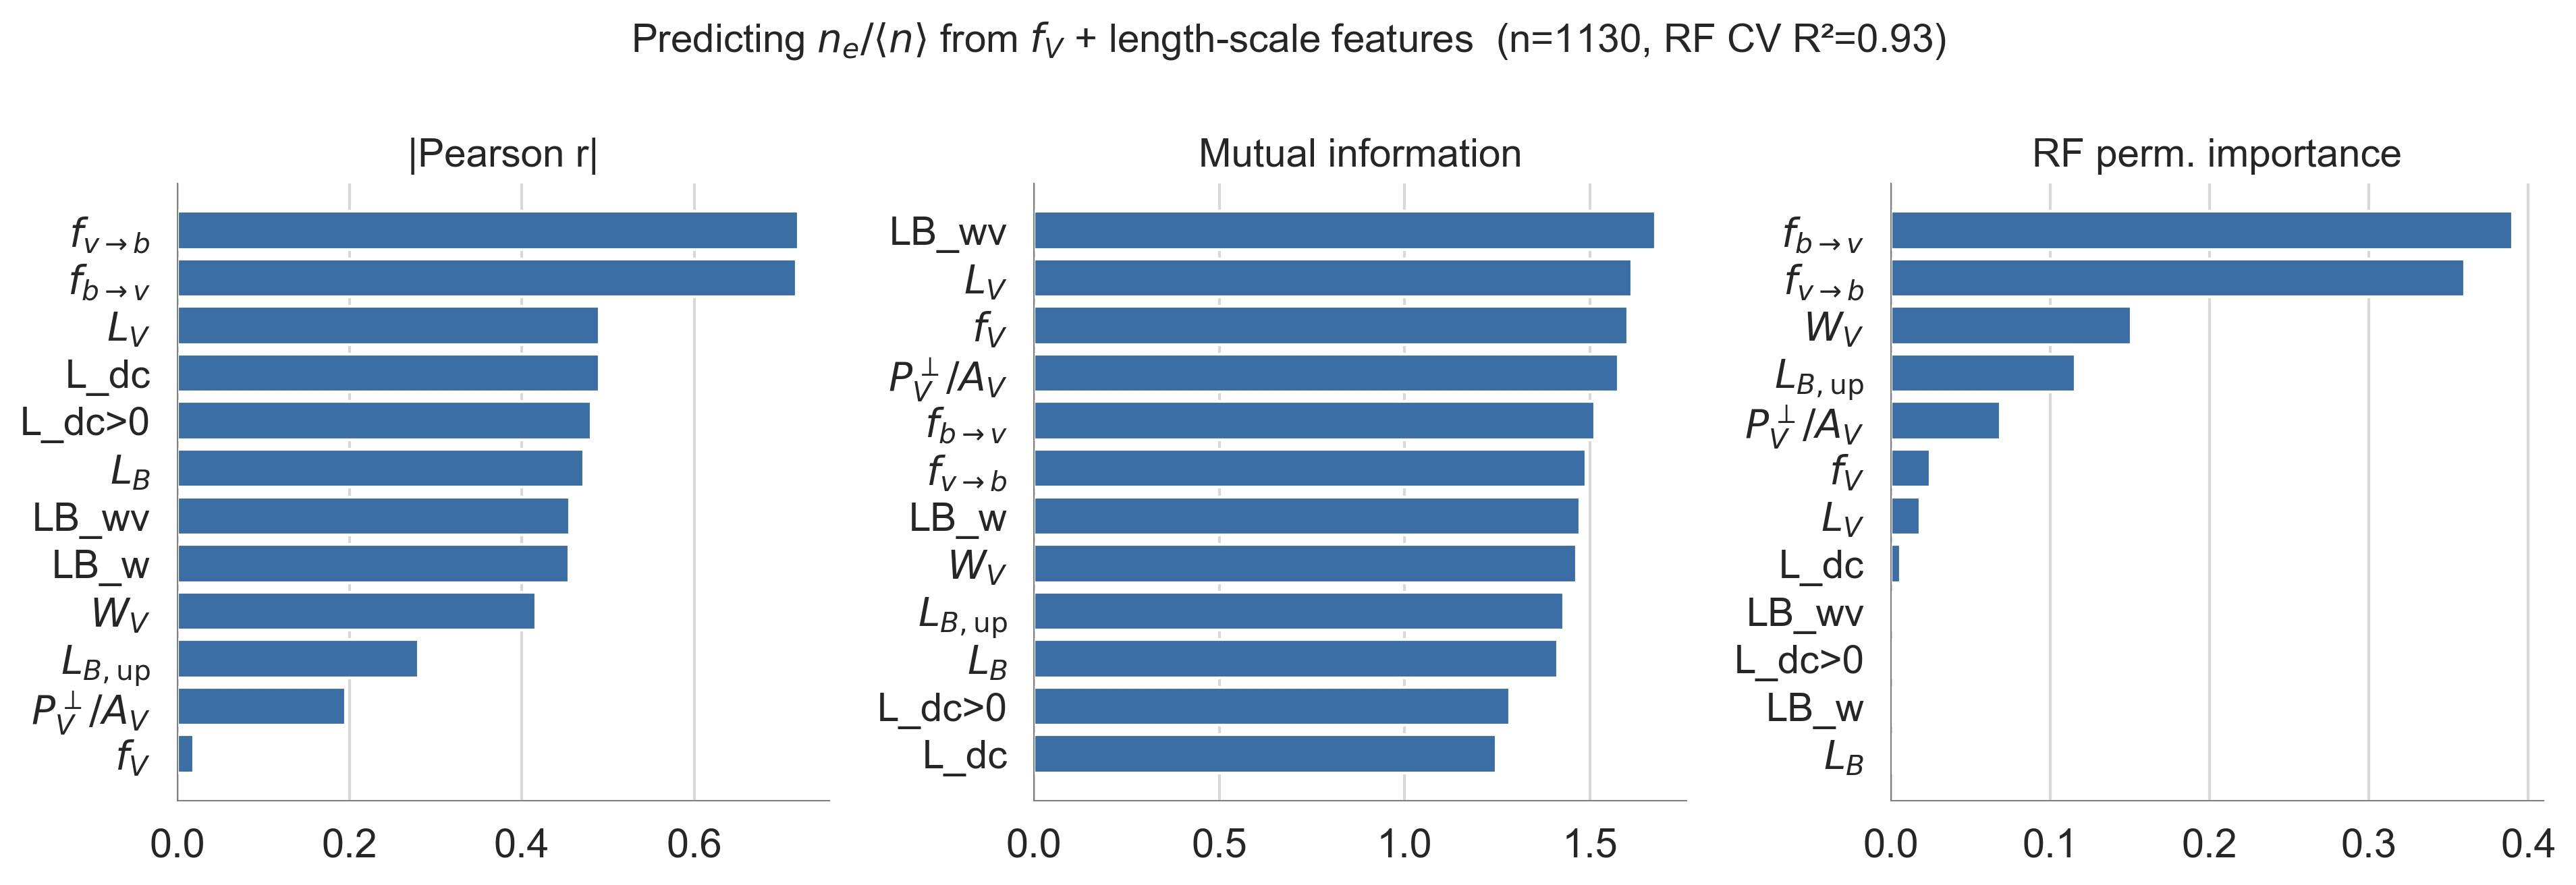

In [9]:
# === Feature selection: fV + length-scale predictors vs effect_ratio ===
# Predictors: fV plus scalar fields added by add_lengthscales (read_SWOF.py).
# Excludes array-valued fields (patch_LV, LV_dist, ...).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold

_feat_cols = ['fV', 'LV', 'uB', 'WV_avg', 'L_dc', 'L_dc>0',
              'LB_w', 'LB_wv', 'LB', 'bare_to_veg', 'veg_to_bare', 'edge']
_target    = 'effect_ratio'

# Keep only columns that exist and are numeric
_have = [c for c in _feat_cols if c in summary.columns]
_missing = [c for c in _feat_cols if c not in summary.columns]
if _missing:
    print(f'Skipping missing columns: {_missing}')

_df = summary[_have + [_target]].apply(pd.to_numeric, errors='coerce').dropna()
X = _df[_have].to_numpy(float)
y = _df[_target].to_numpy(float)
print(f'n samples = {len(_df)},  n features = {X.shape[1]}')

# --- 1) |Pearson r| ---
_pearson = _df[_have].corrwith(_df[_target]).abs().sort_values(ascending=False)

# --- 2) Mutual information ---
_mi = pd.Series(
    mutual_info_regression(X, y, random_state=0),
    index=_have,
).sort_values(ascending=False)

# --- 3) RF permutation importance + CV R^2 ---
_rf = RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1)
_rf.fit(X, y)
_perm = permutation_importance(_rf, X, y, n_repeats=20, random_state=0, n_jobs=-1)
_rf_imp = pd.Series(_perm.importances_mean, index=_have).sort_values(ascending=False)

_cv = cross_val_score(_rf, X, y, cv=KFold(5, shuffle=True, random_state=0),
                      scoring='r2', n_jobs=-1)
print(f'RF 5-fold CV R^2 = {_cv.mean():.3f} +/- {_cv.std():.3f}')

# --- combine into one ranking table ---
_rank = pd.DataFrame({
    '|Pearson r|':         _pearson,
    'Mutual info':         _mi,
    'RF perm. importance': _rf_imp,
}).reindex(_have)
_rank['mean_rank'] = _rank.rank(ascending=False).mean(axis=1)
_rank = _rank.sort_values('mean_rank')
display(_rank.round(4))

# --- plot the three rankings as horizontal bars ---
_, _scratch, _ = _fig_dirs()
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, (name, s) in zip(axes, [('|Pearson r|',         _pearson),
                                ('Mutual information',  _mi),
                                ('RF perm. importance', _rf_imp)]):
    s = s.sort_values()
    ax.barh(range(len(s)), s.values, color='#3a6ea5')
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels([renameit(c, rename) for c in s.index], fontsize=FS_TICK)
    ax.set_title(name, fontsize=FS_TITLE)
    ax.grid(axis='x', alpha=0.3)
fig.suptitle(f'Predicting {renameit(_target, rename)} from {renameit("fV", rename)} + length-scale features'
             f'  (n={len(_df)}, RF CV R²={_cv.mean():.2f})',
             fontsize=FS_TITLE)
fig.tight_layout()
fig.savefig(f'{_scratch}/feature_selection_lengthscales.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# --------------------------- configuration ---------------------------
target_col  = "<Sf>_nbar2_Ubar2"          # y (means-only term already in your df)
feat_cols   = ["<U>", "<h>", "<n>"]     # X: Ua, ha, n
cv_folds    = 5
rng_seed    = 42

# --------------------------- data prep ---------------------------
if target_col not in summary.columns:
    raise KeyError(f"Missing '{target_col}' in dataframe.")

missing = [c for c in feat_cols if c not in summary.columns]
if missing:
    raise KeyError(f"Missing feature columns: {missing}")

df = summary[[target_col, *feat_cols]].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# positivity for log-transform
pos_mask = (df[target_col] > 0)
for c in feat_cols:
    pos_mask &= (df[c] > 0)

df = df.loc[pos_mask].copy()
if df.empty:
    raise ValueError("No valid rows after filtering for positivity & non-NaNs.")

y  = df[target_col].to_numpy(dtype=float)
Ua = df["<U>"].to_numpy(dtype=float)
ha = df["<h>"].to_numpy(dtype=float)
nn = df["<n>"].to_numpy(dtype=float)

N = len(df)

print("=" * 55)
print("FITTING SUMMARY")
print("=" * 55)
print(f"  Target  (y) : {target_col}")
print(f"  Features (X): {feat_cols}")
print(f"  Rows used   : N = {N}  (after NaN + positivity filter)")
print("=" * 55)

# --------------------------- helper metrics ---------------------------
def r2(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan
    ssr = np.sum((y_true[m] - y_pred[m])**2)
    sst = np.sum((y_true[m] - np.mean(y_true[m]))**2)
    return 1.0 - ssr/sst if sst > 0 else np.nan

def rmse(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(np.nanmean((y_true[m] - y_pred[m])**2))

# --------------------------- (1) free power-law fit ---------------------------
# log y = alpha + a*log Ua + b*log ha + c*log n
logy  = np.log(y)
X_log = np.column_stack([np.ones(N), np.log(Ua), np.log(ha), np.log(nn)])

beta, *_ = np.linalg.lstsq(X_log, logy, rcond=None)
alpha, a_hat, b_hat, c_hat = beta

# standard errors & 95% CI in log-space
resid   = logy - X_log @ beta
p       = X_log.shape[1]
dof     = max(N - p, 1)
sigma2  = float(np.sum(resid**2) / dof)
# Use pseudo-inverse for stability
XtX_inv = np.linalg.pinv(X_log.T @ X_log)
se      = np.sqrt(np.diag(sigma2 * XtX_inv))

alpha_ci = (alpha - 1.96*se[0], alpha + 1.96*se[0])
a_ci     = (a_hat - 1.96*se[1], a_hat + 1.96*se[1])
b_ci     = (b_hat - 1.96*se[2], b_hat + 1.96*se[2])
c_ci     = (c_hat - 1.96*se[3], c_hat + 1.96*se[3])

A_hat = np.exp(alpha)
y_pred_free = A_hat * (Ua**a_hat) * (ha**b_hat) * (nn**c_hat)

print("\n--- Free power-law fit (log-space OLS) ---")
print(f"log A  = {alpha: .3f}  (95% CI: {alpha_ci[0]: .3f}, {alpha_ci[1]: .3f})")
print(f"a (U) = {a_hat: .3f}  (95% CI: {a_ci[0]: .3f}, {a_ci[1]: .3f})")
print(f"b (h) = {b_hat: .3f}  (95% CI: {b_ci[0]: .3f}, {b_ci[1]: .3f})")
print(f"c (n ) = {c_hat: .3f}  (95% CI: {c_ci[0]: .3f}, {c_ci[1]: .3f})")
print(f"R^2 (linear space) = {r2(y, y_pred_free):.3f}")
print(f"RMSE (linear space)= {rmse(y, y_pred_free):.3e}")

# --------------------------- (2) physics-anchored exponents ---------------------------
# Fixed a=2, b=-4/3, c=2; fit only alpha (i.e., A) in log-space
a_fix, b_fix, c_fix = 2.0, -4.0/3.0, 2.0
logX_fix = (a_fix*np.log(Ua) + b_fix*np.log(ha) + c_fix*np.log(nn))
alpha_fix = float(np.mean(logy - logX_fix))  # least-squares intercept
A_fix = float(np.exp(alpha_fix))
y_pred_phys = A_fix * (Ua**a_fix) * (ha**b_fix) * (nn**c_fix)

print("\n--- a=2, b=-4/3, c=2; fit A only ---")
print(f"log A  = {alpha_fix: .3f}  ->  A = {A_fix:.3e}")
print(f"R^2 (linear space) = {r2(y, y_pred_phys):.3f}")
print(f"RMSE (linear space)= {rmse(y, y_pred_phys):.3e}")


FITTING SUMMARY
  Target  (y) : <Sf>_nbar2_Ubar2
  Features (X): ['<U>', '<h>', '<n>']
  Rows used   : N = 1260  (after NaN + positivity filter)

--- Free power-law fit (log-space OLS) ---
log A  =  0.000  (95% CI:  0.000,  0.000)
a (U) =  2.000  (95% CI:  2.000,  2.000)
b (h) = -1.333  (95% CI: -1.333, -1.333)
c (n ) =  2.000  (95% CI:  2.000,  2.000)
R^2 (linear space) = 1.000
RMSE (linear space)= 5.222e-17

--- a=2, b=-4/3, c=2; fit A only ---
log A  = -0.000  ->  A = 1.000e+00
R^2 (linear space) = 1.000
RMSE (linear space)= 3.044e-18


## Tracer flow visuals

_Visual diagnostics of tracer transport under varying storm intensities and durations._


In [11]:
def format_plot(summary, xfld, yfld, cfld, cmap = cm.ocean, 
                alpha = 0.5, err_tol = 0.1, vmax = None, vmin = None,
                s = None, edgecolor = None):
    '''
    Will create a color-coded scatter plot for tracer fields
    '''
    if err_tol:
        inds = summary.query('abs_err < {0}'.format(err_tol)).index
    else: 
        inds = summary.index
    c = plt.scatter(summary.loc[inds][xfld].astype(float), 
                summary.loc[inds][yfld].astype(float), 
                c = summary.loc[inds][cfld].astype(float),  cmap = cmap, visible = 0, vmin = vmin, vmax = vmax)

    plt.scatter(summary.loc[inds][xfld].astype(float),  
                summary.loc[inds][yfld].astype(float),  
                c = summary.loc[inds][cfld].astype(float),  cmap = cmap, alpha =alpha,
                vmin = vmin, edgecolor = edgecolor,
                 vmax = vmax, s = s)

    plt.xlabel(format_name(xfld))
    plt.ylabel(format_name(yfld))
    plt.colorbar(c ,label = format_name(cfld))


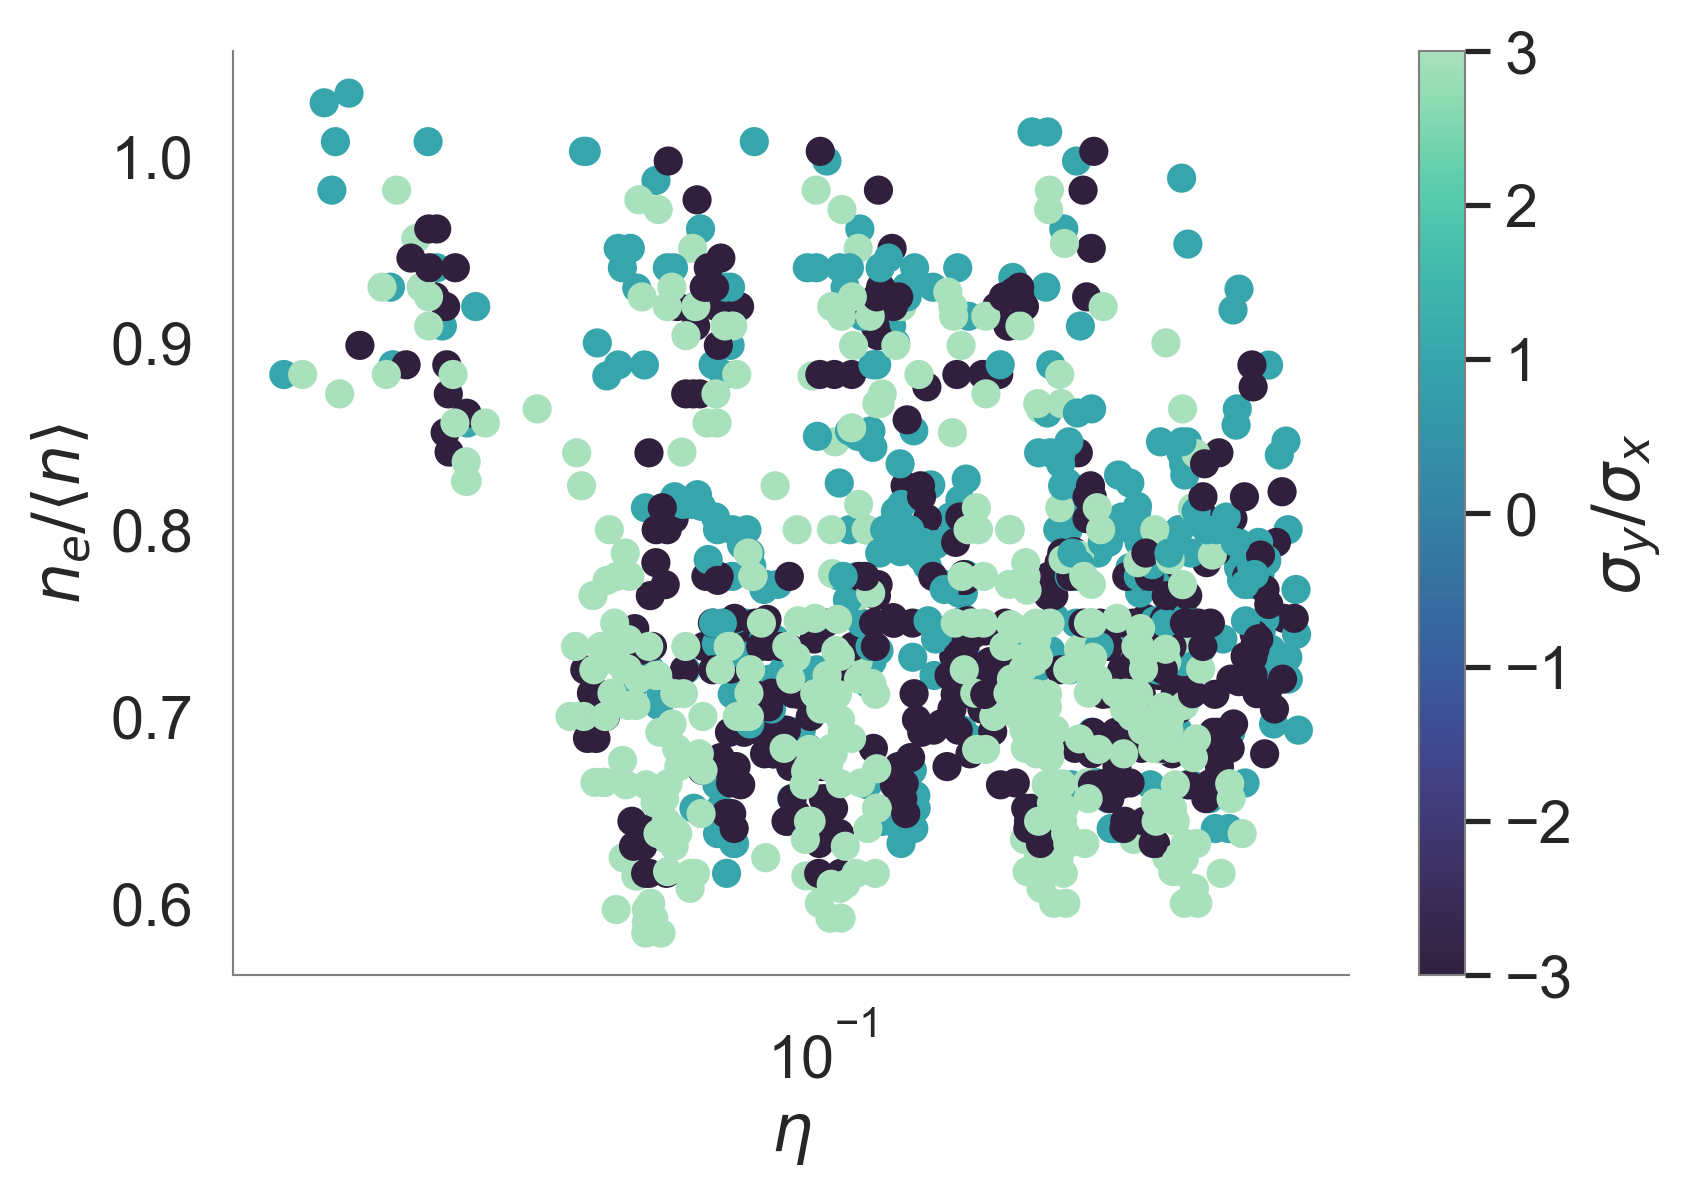

In [12]:
plt.figure(figsize = (6,4))
cfld = "aniso"
xfld = "curve"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and fV > 0.1 and l == 200")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])
plt.gca().set_xscale('log')
subset[['effect_ratio', 'curve']].corr().iloc[0, 1]
plt.show()


np.float64(-0.1582888187653669)

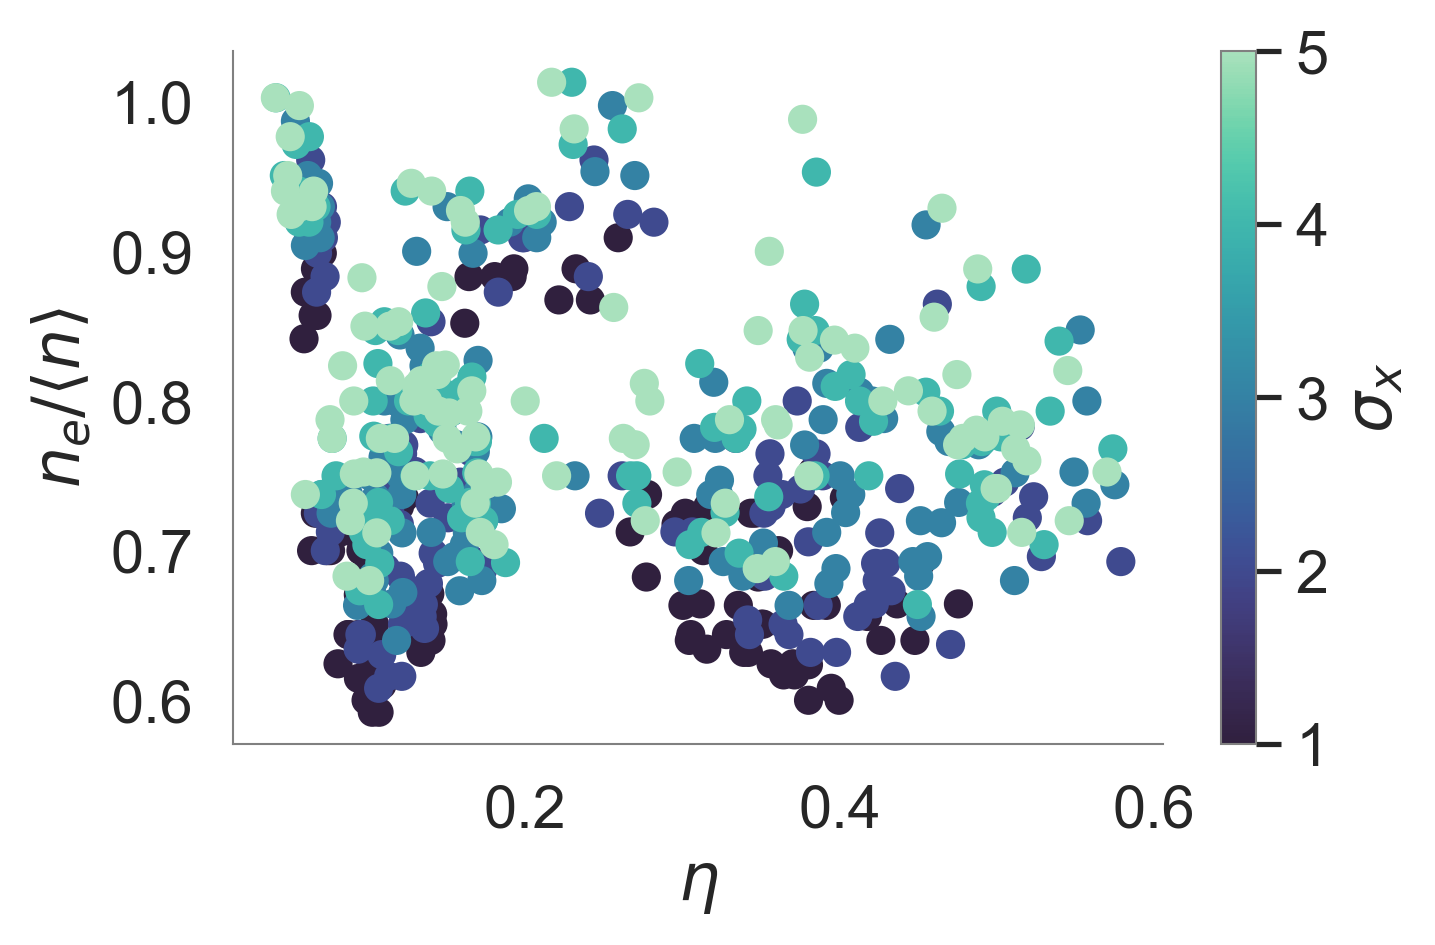

In [13]:
# tortuosity here looks really low – visuals from GRL paper?
cfld = "sigma"
xfld = "curve"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and fV > 0.15   and tr == 60")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])

subset[['effect_ratio', 'curve']].corr().iloc[0, 1]


np.float64(-0.2537869110573282)

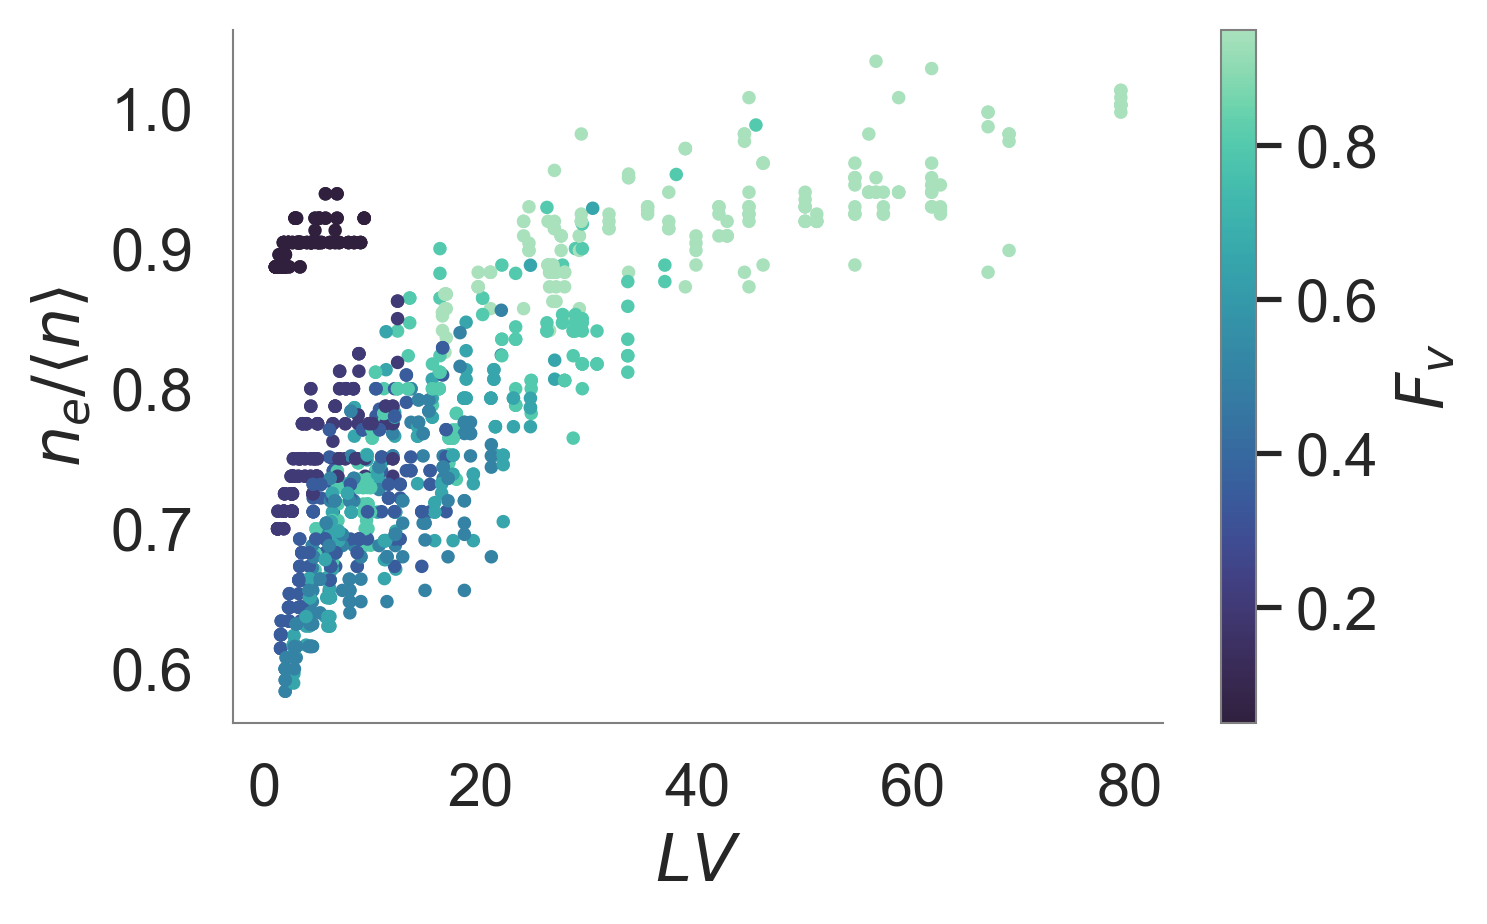

In [14]:
# tortuosity here looks really low – visuals from GRL paper?
xfld = "LV"
cfld = "fV"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and l > 10")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1, s=5)
plt.ylabel(rename[yfld])
# plt.gca().set_xscale('log')
subset[['effect_ratio', 'curve']].corr().iloc[0, 1]


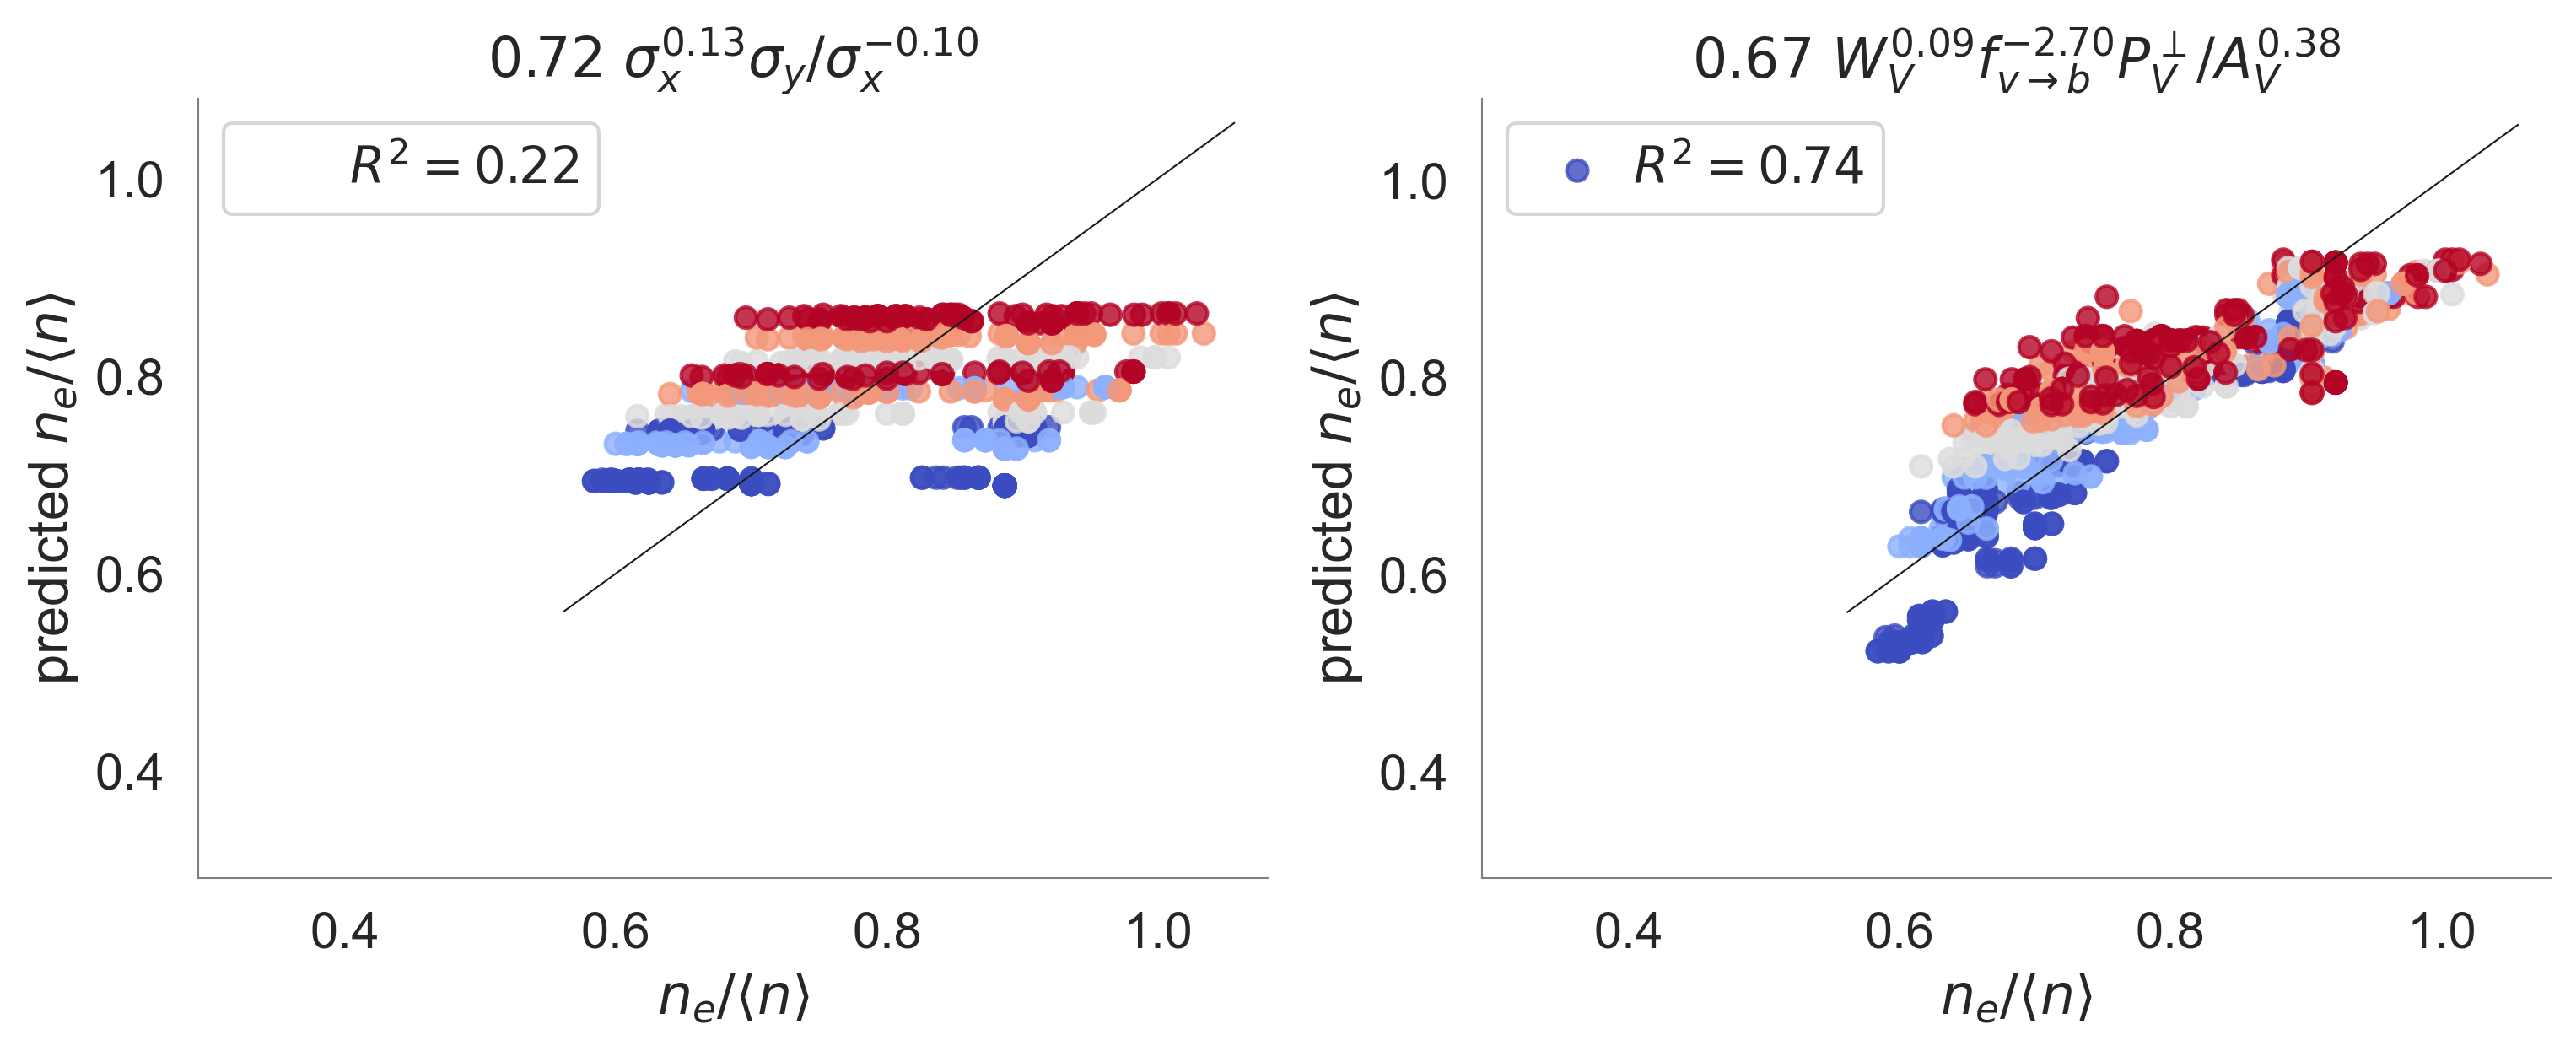

In [18]:
def nrmse(x,y):
    
    return np.sqrt(np.sum((x - y)**2)/np.size(x))/np.mean(x)

def dislay_fit(subset, ax, target = 'effect_ratio_hydro',  cols = ['fV', 'l'], 
               cfld = "fV", colorbar = False):

    subset = subset.copy()   # prevent in-place mutation of the caller's DataFrame
    subset[cols] += 1

    res, subset, equation = wrap_fit(subset, cols , target )

    # Substitute LaTeX labels from `rename` for raw column names. Skip
    # columns already handled by the legacy `names` dict (those were
    # already substituted inside make_equation, e.g. sigma -> \sigma_x);
    # re-replacing them would clobber the existing LaTeX. Also account for
    # the cosmetic _avg/_reg mangling that make_equation applies.
    for _col in sorted(set(cols) | {target}, key=len, reverse=True):
        if _col in names or _col not in rename:
            continue
        _tex = rename[_col].strip('$')
        _mangled = _col.replace('_avg', '_{avg}').replace('_reg', '_{reg}')
        equation = equation.replace(_mangled, _tex)
        if _mangled != _col:
            equation = equation.replace(_col, _tex)
    nrmse_val = nrmse(subset[target], make_prediction(res, cols, subset))
    
    c = ax.scatter( 
                 (subset[target]), 
                 (make_prediction(res, cols, subset)),
                 c = subset[cfld], alpha = 0.8, label = '$R^2 = {0:.2f}$'.format(res.rsquared, nrmse_val),
                 cmap = "coolwarm")

    ax.legend(loc = 'upper left', handletextpad=0.1)
    if colorbar == True:
        cbaxes = fig.add_axes([0.91, 0.1, 0.008, 0.75])
        plt.colorbar(c, label = format_name(cfld), cax  = cbaxes)

    ax.set_xlabel(format_name(target).replace("m1", "T"));
    ax.set_ylabel( 'predicted ' + format_name(target).replace("m1", "T"));

    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x, c = 'k', lw = .5)


    ax.set_ylim(np.percentile(subset[target].dropna(), 0)/2, )
    ax.set_xlim(np.percentile(subset[target].dropna(), 0)/2, )

    return ax, equation, res

fig, axes = plt.subplots(1, 2, figsize = (12,4))

ax = axes[0]
ax, equation, res = dislay_fit(summary.query("fV >0"), ax = ax,
                               target = 'effect_ratio',  cfld = 'sigma',
                               cols = [  'fV',  'sigma',  'aniso'])

ax.set_xlabel(r"$n_e/ \langle n \rangle$")
ax.set_ylabel(r"predicted $n_e/ \langle n \rangle$")
ax.set_title(equation)

ax = axes[1]
ax, equation, res = dislay_fit(summary.query("fV >0"), ax = ax,
                               target = 'effect_ratio',  cfld = 'sigma',
                               cols = [   'WV_avg',  'veg_to_bare','edge',])

ax.set_xlabel(r"$n_e/ \langle n \rangle$")
ax.set_ylabel(r"predicted $n_e/ \langle n \rangle$")

ax.set_title(equation)
plt.show()

## Controlled predictor analysis

For each of the top-8 features (by RF permutation importance), ask:

> **Does the predictor remain significant after controlling for the other seven?**

Because the outcome here is continuous ($n_e/\langle n\rangle$), we use OLS rather than logistic regression. The drop-one *likelihood-ratio test* of the binary-outcome case becomes a *partial F-test* (equivalent to the LRT for Gaussian errors).

Methods per predictor:

1. **Univariate association** — OLS of $n_e/\langle n\rangle$ on the focal predictor alone; reports the slope, its $t$-statistic, and the univariate $R^2$.
2. **Multivariate OLS — focal coefficient** — all 8 predictors entered simultaneously; the coefficient is the partial effect *after holding the other seven constant*. Comparing univariate and multivariate coefficients exposes confounding (univariate-only) and suppression (multivariate-only).
3. **Drop-one partial F-test** — fit a *reduced* model without the focal predictor and compare against the full model:
   $$F = \frac{(SSR_{\rm red}-SSR_{\rm full})/q}{SSR_{\rm full}/(n-p-1)}$$
   with $q=1$ d.f. for the focal predictor. A significant test means the predictor adds explanatory power beyond the other seven. We also report $\Delta R^2$ and $\Delta\text{AIC} = \text{AIC}_{\rm red}-\text{AIC}_{\rm full}$; $\Delta\text{AIC}>2$ indicates a meaningful independent contribution.
4. **Random-forest permutation importance** — model-agnostic robustness check, fit on the same 8-feature set.

Predictors are standardised before fitting so that OLS coefficients are directly comparable (a 1-σ change in the predictor → $\beta$ change in $n_e/\langle n\rangle$).


In [21]:
# === Controlled predictor analysis (top-8 RF features, OLS + partial F) ===
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import f as f_dist
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold
from IPython.display import display

_cp_target = 'effect_ratio'
_cp_candidates = ['fV', 'LV', 'uB', 'WV_avg', 'L_dc', 'L_dc>0',
                  'LB_w', 'LB_wv', 'LB', 'bare_to_veg', 'veg_to_bare', 'edge']
_cp_have = [c for c in _cp_candidates if c in summary.columns]

_cp_df = summary[_cp_have + [_cp_target]].apply(pd.to_numeric, errors='coerce').dropna()
_X_all = _cp_df[_cp_have].to_numpy(float)
_y_all = _cp_df[_cp_target].to_numpy(float)

# ── 1) Rank features by RF permutation importance, take top 8 ────────────
_rf0 = RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1)
_rf0.fit(_X_all, _y_all)
_perm0 = permutation_importance(_rf0, _X_all, _y_all,
                                n_repeats=20, random_state=0, n_jobs=-1)
_rf_rank = (pd.Series(_perm0.importances_mean, index=_cp_have)
              .sort_values(ascending=False))
_TOP_K = 8
_top_feats = _rf_rank.head(_TOP_K).index.tolist()
print(f"n = {len(_cp_df)};  top-{_TOP_K} RF features: {_top_feats}")

# ── 2) Build (standardised) design matrix on top-K features ──────────────
_Xtop = _cp_df[_top_feats].astype(float)
_Xz   = (_Xtop - _Xtop.mean()) / _Xtop.std(ddof=0)
_y    = _cp_df[_cp_target].astype(float)

# Full OLS
_X_full = sm.add_constant(_Xz)
_full   = sm.OLS(_y, _X_full).fit()
_n, _p_full = _X_full.shape
print(f"Full OLS: R² = {_full.rsquared:.3f}, "
      f"adj R² = {_full.rsquared_adj:.3f}, AIC = {_full.aic:.1f}")

# ── 3) Per-focal univariate + drop-one partial F ─────────────────────────
_rows = []
for feat in _top_feats:
    # Univariate OLS
    _Xu  = sm.add_constant(_Xz[[feat]])
    _uni = sm.OLS(_y, _Xu).fit()

    # Reduced model (drop just this feature)
    _Xr  = _X_full.drop(columns=[feat])
    _red = sm.OLS(_y, _Xr).fit()

    # Partial F-test (1 d.f.)
    _df_num   = 1
    _df_den   = _n - _p_full
    _ssr_red  = float(_red.ssr)
    _ssr_full = float(_full.ssr)
    _F        = (_ssr_red - _ssr_full) / _df_num / (_ssr_full / _df_den)
    _F_p      = float(f_dist.sf(_F, _df_num, _df_den))
    _dR2      = _full.rsquared - _red.rsquared
    _dAIC     = _red.aic - _full.aic

    _b   = _full.params[feat]
    _se  = _full.bse[feat]
    _lo, _hi = _b - 1.96 * _se, _b + 1.96 * _se

    _rows.append({
        'Predictor':           renameit(feat, rename),
        'Column':              feat,
        'Univariate β (std)':  _uni.params[feat],
        'Univariate p':        _uni.pvalues[feat],
        'Univariate R²':       _uni.rsquared,
        'Controlled β (std)':  _b,
        'Controlled 95% CI':   f"({_lo:+.3f}, {_hi:+.3f})",
        'Coef p':              _full.pvalues[feat],
        'Partial F':           _F,
        'F p':                 _F_p,
        'ΔR²':                 _dR2,
        'ΔAIC':                _dAIC,
        'RF perm. importance': _rf_rank[feat],
    })

_cp_summary = pd.DataFrame(_rows)
_cp_summary['sig (uni)']   = _cp_summary['Univariate p'].apply(
    lambda p: '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'ns')
_cp_summary['sig (ctrl)']  = _cp_summary['F p'].apply(
    lambda p: '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'ns')

print("\n── Per-predictor results ──")
display(_cp_summary.style.format({
    'Univariate β (std)':  '{:+.3f}',
    'Univariate p':        '{:.4g}',
    'Univariate R²':       '{:.3f}',
    'Controlled β (std)':  '{:+.3f}',
    'Coef p':              '{:.4g}',
    'Partial F':           '{:.2f}',
    'F p':                 '{:.4g}',
    'ΔR²':                 '{:+.3f}',
    'ΔAIC':                '{:+.1f}',
    'RF perm. importance': '{:.3f}',
}).hide(axis='index'))

# 5-fold CV R² for the 8-feature RF and OLS
_rf = RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1)
_kf = KFold(5, shuffle=True, random_state=0)
_rf_cv  = cross_val_score(_rf, _Xtop.to_numpy(), _y.to_numpy(),
                          cv=_kf, scoring='r2', n_jobs=-1)
print(f"\nRF  5-fold CV R² = {_rf_cv.mean():.3f} ± {_rf_cv.std():.3f}")


n = 1130;  top-8 RF features: ['bare_to_veg', 'veg_to_bare', 'WV_avg', 'uB', 'edge', 'fV', 'LV', 'L_dc']
Full OLS: R² = 0.911, adj R² = 0.910, AIC = -4737.6

── Per-predictor results ──


Predictor,Column,Univariate β (std),Univariate p,Univariate R²,Controlled β (std),Controlled 95% CI,Coef p,Partial F,F p,ΔR²,ΔAIC,RF perm. importance,sig (uni),sig (ctrl)
$f_{b\rightarrow v}$,bare_to_veg,-0.071,4.284e-180,0.516,-0.396,"(-0.473, -0.320)",4.007e-23,102.55,4.007e-23,+0.008,+96.9,0.390,***,***
$f_{v\rightarrow b}$,veg_to_bare,-0.071,4.649e-182,0.520,+0.325,"(+0.248, +0.403)",5.037e-16,67.78,5.037e-16,+0.005,+64.3,0.360,***,***
$W_V$,WV_avg,+0.041,1.747e-48,0.173,+0.035,"(+0.032, +0.038)",2.458e-88,476.65,2.458e-88,+0.038,+398.4,0.151,***,***
"$L_{B,\mathrm{up}}$",uB,+0.028,8.496e-22,0.078,+0.002,"(-0.001, +0.005)",0.1274,2.33,0.1274,+0.000,+0.3,0.116,***,ns
$P_V^{\perp}/A_V$,edge,-0.019,3.615e-11,0.038,+0.077,"(+0.073, +0.082)",4.919e-184,1244.93,4.919e-184,+0.099,+842.1,0.068,***,***
$f_V$,fV,-0.002,0.5296,0.000,+0.069,"(+0.063, +0.075)",1.002e-87,472.66,1.002e-87,+0.038,+395.5,0.025,ns,***
$L_V$,LV,+0.048,2.698e-69,0.240,+0.015,"(+0.012, +0.019)",7.954e-18,76.49,7.954e-18,+0.006,+72.6,0.018,***,***
L_dc,L_dc,+0.048,3.009e-69,0.240,+0.068,"(+0.065, +0.071)",3.356e-240,1858.50,3.356e-240,+0.148,+1102.6,0.006,***,***



RF  5-fold CV R² = 0.931 ± 0.017


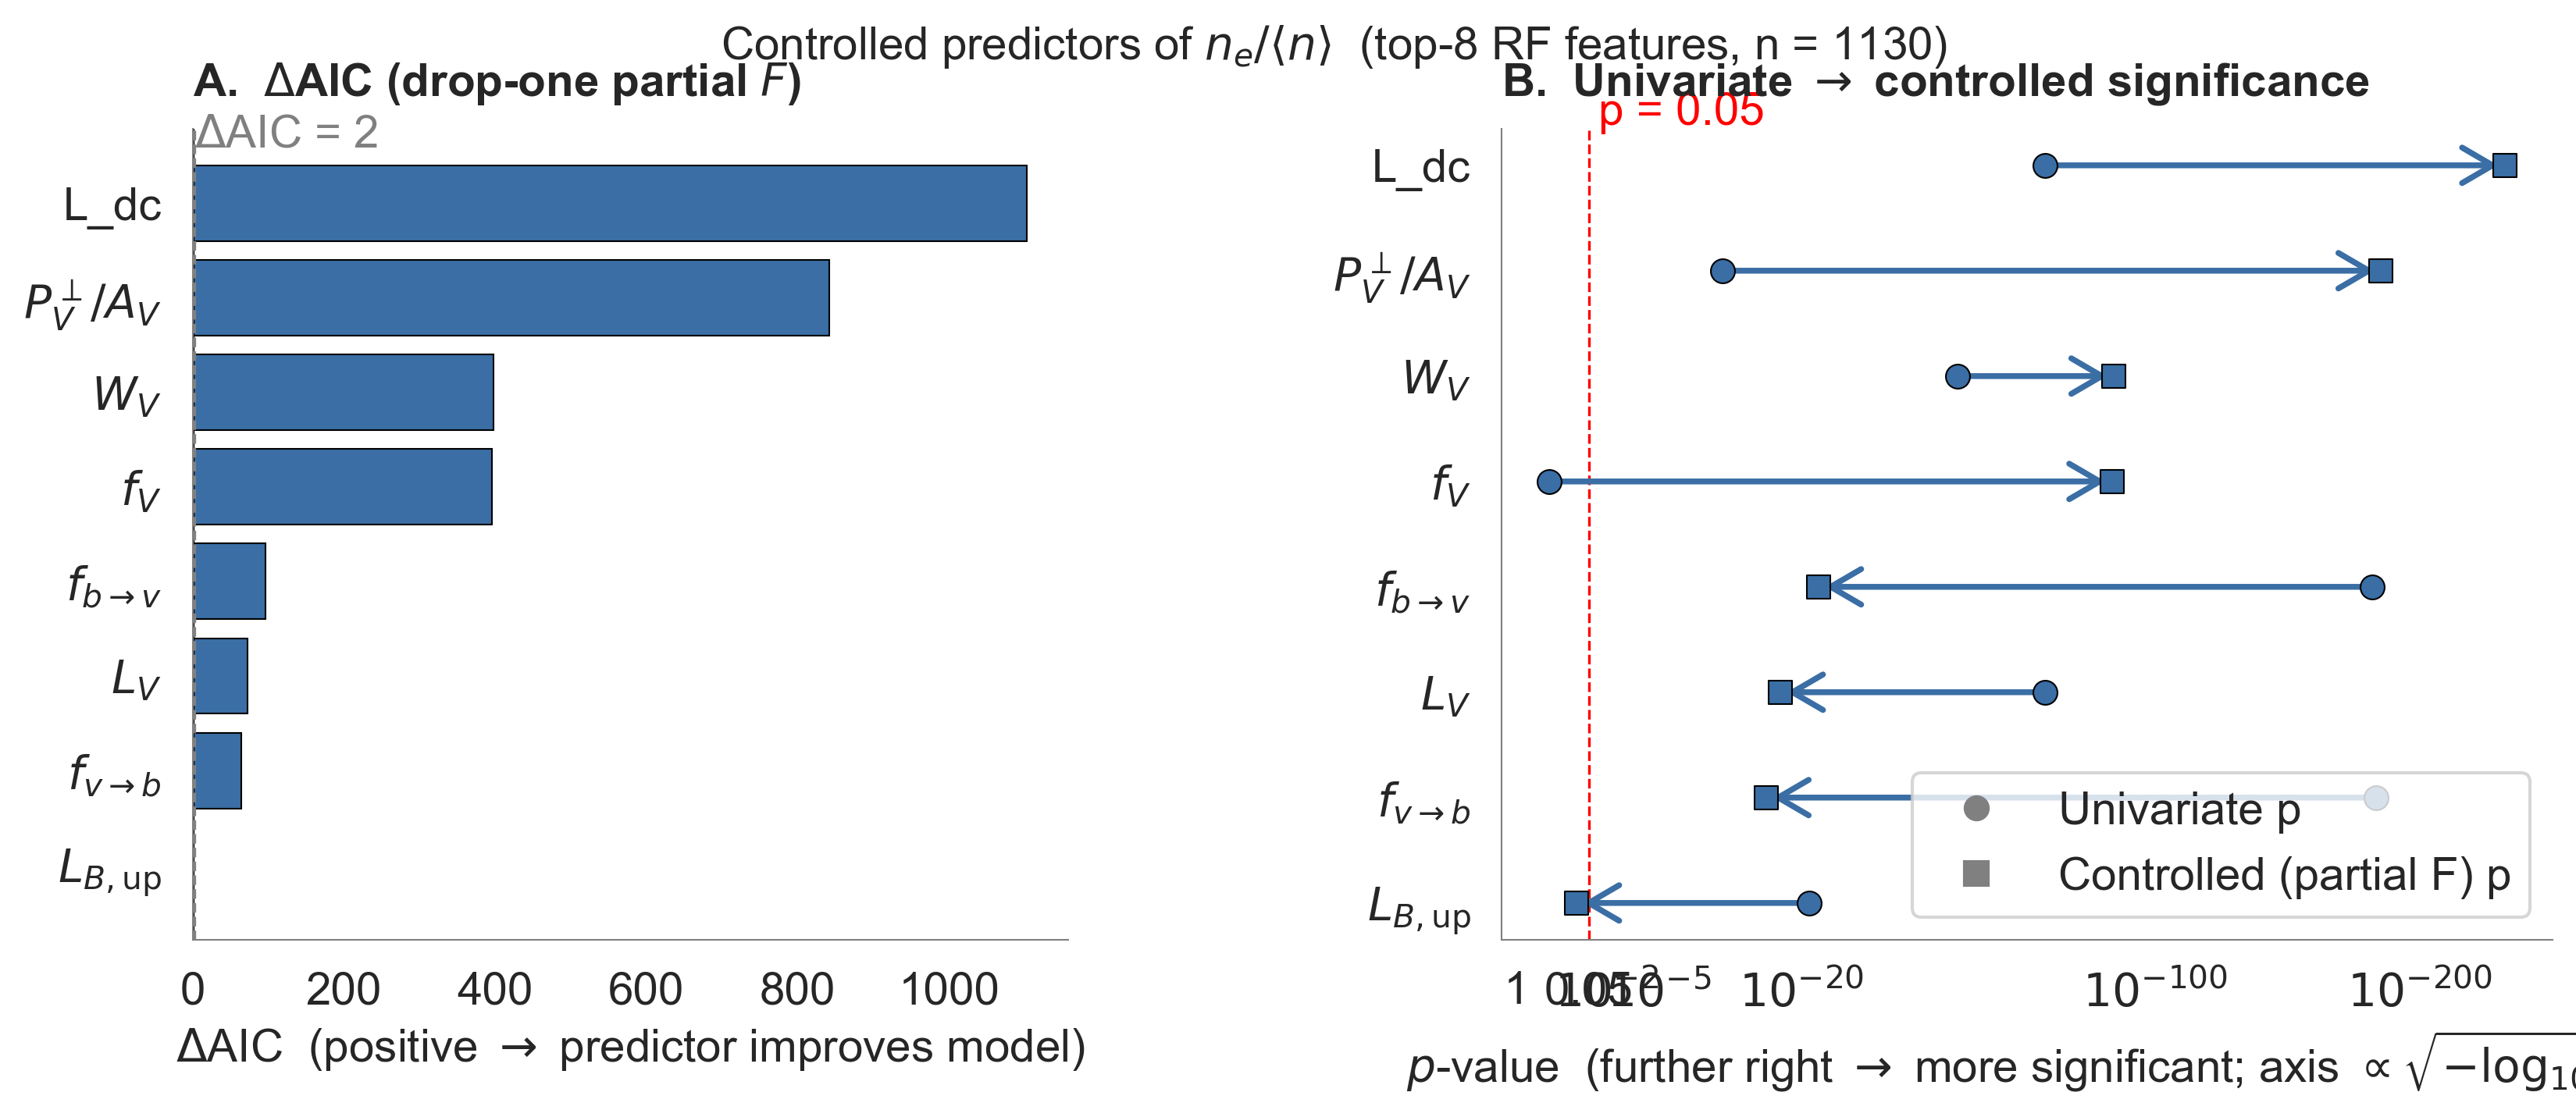

In [24]:
# === Visualisation: ΔAIC bars + univariate→controlled significance shift ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# Sort by ΔAIC ascending so biggest bars are at the top
_viz = _cp_summary.copy().sort_values('ΔAIC', ascending=True).reset_index(drop=True)
_n_v = len(_viz)
_yp  = np.arange(_n_v)

# No artificial cap on -log10(p): with n=1130, p can be ~1e-240 for several
# predictors. We compress with sqrt() so the few extreme values don't squash
# the rest of the panel. Threshold p=0.05 -> sqrt(-log10(0.05)) ≈ 1.14.
def _nl(p):
    return float(np.sqrt(-np.log10(max(p, 1e-300))))
_thresh = _nl(0.05)

fig = plt.figure(figsize=(13, 4.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.45)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Panel A: ΔAIC horizontal bars ────────────────────────────────────────
_clr = '#3a6ea5'
ax1.barh(_yp, _viz['ΔAIC'], color=_clr, edgecolor='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.axvline(2, color='grey', linewidth=0.8, linestyle='--')
ax1.text(2.4, _n_v - 0.5, r'$\Delta$AIC = 2', fontsize=FS_LABEL, color='grey', va='bottom')
ax1.set_yticks(_yp)
ax1.set_yticklabels(_viz['Predictor'], fontsize=FS_TICK)
ax1.set_xlabel(r'$\Delta$AIC  (positive $\rightarrow$ predictor improves model)',
               fontsize=FS_LABEL)
ax1.set_title(r'A.  $\Delta$AIC (drop-one partial $F$)',
              fontsize=FS_TITLE, fontweight='bold', loc='left', pad=10)
ax1.tick_params(labelsize=FS_TICK)
ax1.spines[['top', 'right']].set_visible(False)

# ── Panel B: univariate → controlled significance shift ─────────────────
_min_gap = 0.08  # in compressed sqrt(-log10 p) units
for i, row in _viz.iterrows():
    _u, _l = _nl(row['Univariate p']), _nl(row['F p'])
    if abs(_l - _u) >= _min_gap:
        ax2.annotate('', xy=(_l, i), xytext=(_u, i),
                     arrowprops=dict(arrowstyle='->,head_length=0.6,head_width=0.35',
                                     color=_clr, lw=1.8))
    ax2.scatter(_u, i, marker='o', s=55, color=_clr,
                edgecolors='black', linewidth=0.5, zorder=3)
    ax2.scatter(_l, i, marker='s', s=55, color=_clr,
                edgecolors='black', linewidth=0.5, zorder=3)

ax2.axvline(_thresh, color='red', linewidth=0.8, linestyle='--')
ax2.text(_thresh + 0.15, _n_v - 0.7, 'p = 0.05',
         fontsize=FS_LABEL, color='red', va='bottom')

# Custom ticks at meaningful p-values: 0.05, 1e-2, 1e-5, 1e-20, 1e-100, 1e-200
_p_ticks = [1e-200, 1e-100, 1e-20, 1e-5, 1e-2, 0.05, 1.0]
_x_ticks = [_nl(p) for p in _p_ticks]
_x_labels = [r'$10^{-200}$', r'$10^{-100}$', r'$10^{-20}$',
             r'$10^{-5}$', r'$10^{-2}$', '0.05', '1']
ax2.set_xticks(_x_ticks)
ax2.set_xticklabels(_x_labels, fontsize=FS_TICK)
ax2.set_yticks(_yp)
ax2.set_yticklabels(_viz['Predictor'], fontsize=FS_TICK)
ax2.set_xlabel(r'$p$-value  (further right $\rightarrow$ more significant; '
               r'axis $\propto\sqrt{-\log_{10}p}$)',
               fontsize=FS_LABEL)
ax2.set_title(r'B.  Univariate $\rightarrow$ controlled significance',
              fontsize=FS_TITLE, fontweight='bold', loc='left', pad=10)
ax2.tick_params(labelsize=FS_TICK)
ax2.spines[['top', 'right']].set_visible(False)

_handles = [
    Line2D([0], [0], marker='o', color='grey', markerfacecolor='grey',
           markersize=7, linestyle='None', label='Univariate p'),
    Line2D([0], [0], marker='s', color='grey', markerfacecolor='grey',
           markersize=7, linestyle='None', label='Controlled (partial F) p'),
]
ax2.legend(handles=_handles, fontsize=FS_LEG, loc='lower right')

fig.suptitle(f'Controlled predictors of {renameit(_cp_target, rename)}  '
             f'(top-{_TOP_K} RF features, n = {len(_cp_df)})',
             fontsize=FS_TITLE)
fig.tight_layout()
_, _scratch, _ = _fig_dirs()
fig.savefig(f'{_scratch}/controlled_predictors_effect_ratio.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [23]:
print(_cp_summary[['Predictor', 'Univariate p', 'F p', 'ΔAIC']]
      .assign(**{'-log10 uni_p': lambda d: -np.log10(d['Univariate p'].clip(lower=1e-300)),
                 '-log10 F_p':   lambda d: -np.log10(d['F p'].clip(lower=1e-300))})
      .to_string(index=False))


           Predictor  Univariate p           F p        ΔAIC  -log10 uni_p  -log10 F_p
$f_{b\rightarrow v}$ 4.284451e-180  4.006769e-23   96.916899    179.368105   22.397206
$f_{v\rightarrow b}$ 4.648740e-182  5.037070e-16   64.339392    181.332665   15.297822
               $W_V$  1.746521e-48  2.458424e-88  398.376100     47.757826   87.609343
 $L_{B,\mathrm{up}}$  8.495751e-22  1.273768e-01    0.343891     21.070798    0.894910
   $P_V^{\perp}/A_V$  3.614978e-11 4.919434e-184  842.053967     10.441894  183.308085
               $f_V$  5.295883e-01  1.002321e-87  395.548690      0.276062   86.998993
               $L_V$  2.698337e-69  7.953866e-18   72.591305     68.568904   17.099422
                L_dc  3.008807e-69 3.355715e-240 1102.614235     68.521606  239.474215


n (hydro_err < 5%, positive predictors): 1086
(a) Top-3 RF features: ['bare_to_veg', 'veg_to_bare', 'WV_avg']
    log-space adj R² = 0.704
(b) Best power-law subset (k = 6): ['veg_to_bare', 'WV_avg', 'uB', 'edge', 'fV', 'LV']
    log-space adj R² = 0.892
(c) RFECV-selected features (k = 8): ['bare_to_veg', 'veg_to_bare', 'WV_avg', 'uB', 'edge', 'fV', 'LV', 'L_dc']
    5-fold CV R² = 0.970 ± 0.006
Registry updated → ../figures/runaround_smooth/figure_registry.txt  [fig6]


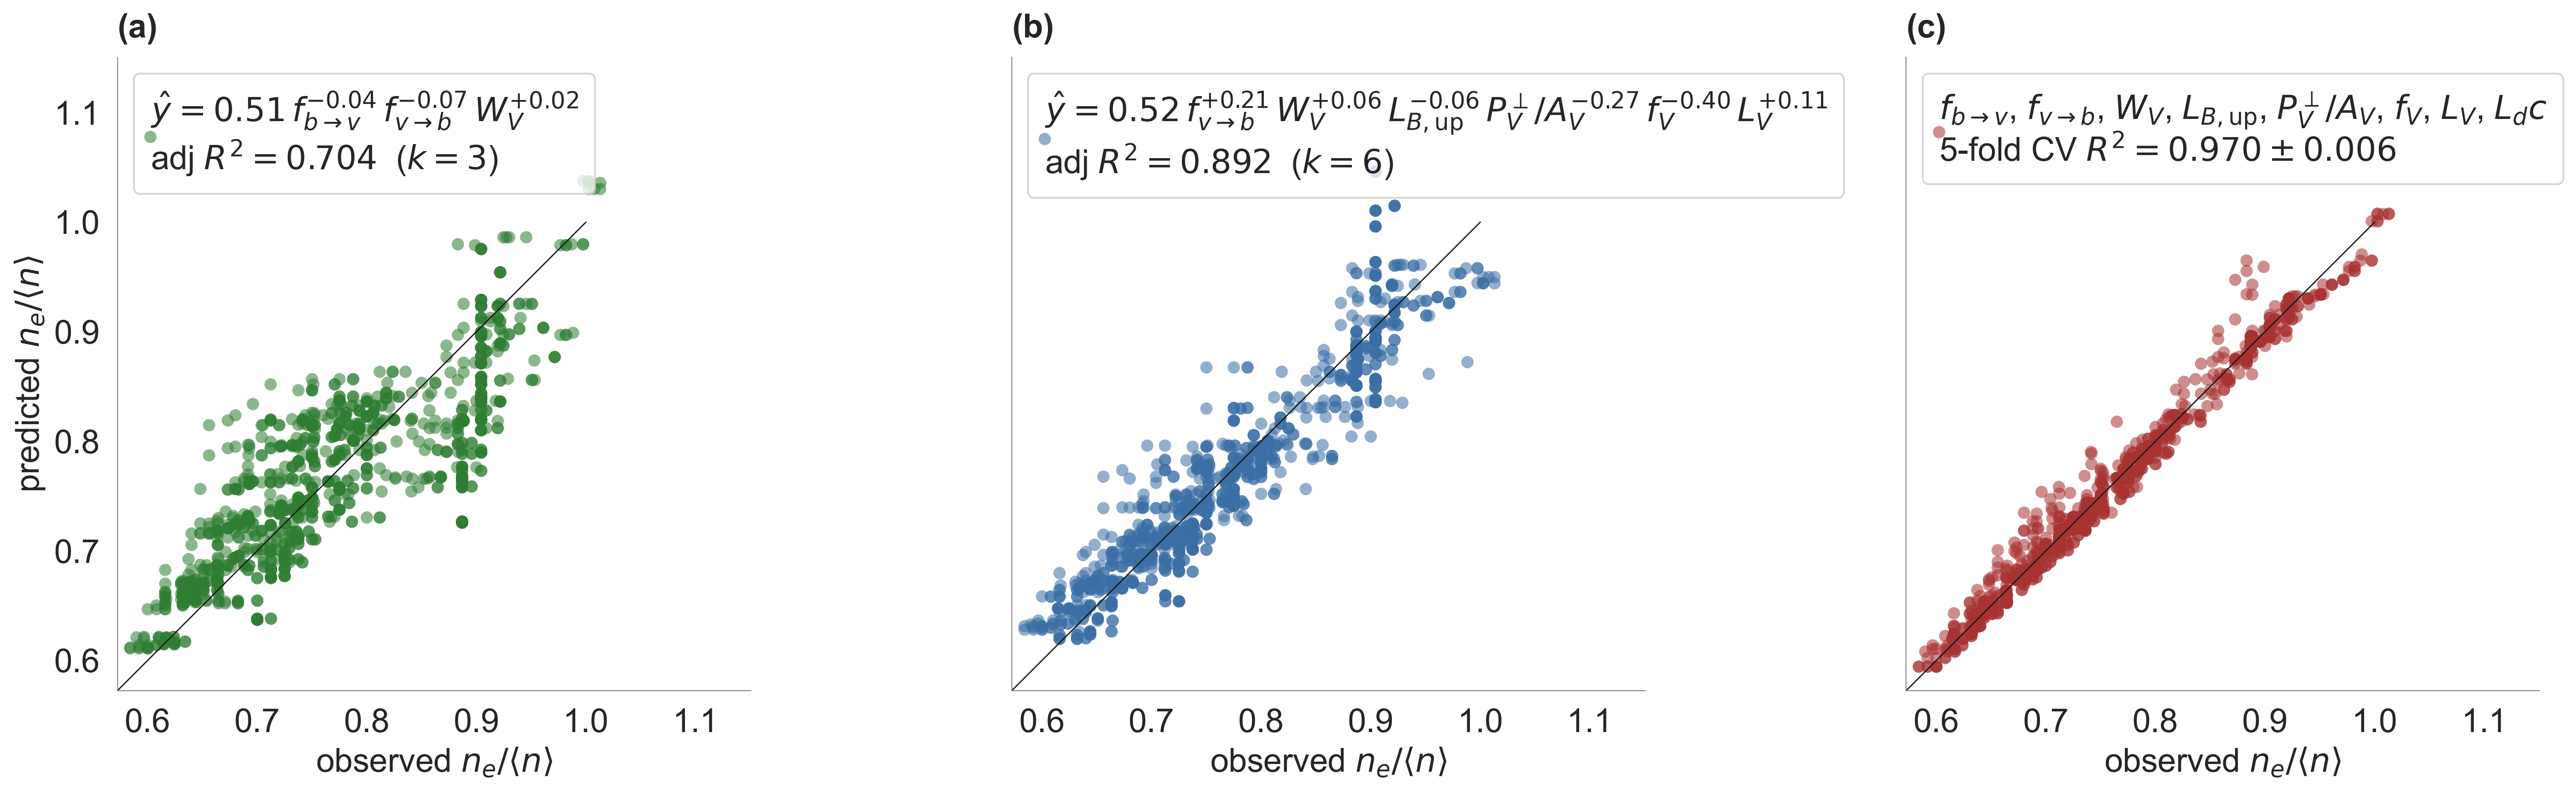

In [39]:
# === Predicted vs observed: (a) top-3 power law, (b) best-subset, (c) RF ===
# Markers in each panel are a single fixed colour (green / blue / red) — they
# are NOT mapped to any data variable; colour only encodes which model produced
# the prediction.
import itertools as _it
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold, cross_val_score

# Single uniform font size for this figure
_FS = 18

# Filter to well-balanced runs (hydro_err < 5%) and positive predictors/target
_hydro_ok   = summary['hydro_err'] < 0.05
_cp_df_h    = _cp_df.loc[_cp_df.index.intersection(summary.index[_hydro_ok])].copy()
_pos_mask   = (_cp_df_h[_top_feats] > 0).all(axis=1) & (_cp_df_h[_cp_target] > 0)
_dfp        = _cp_df_h.loc[_pos_mask].copy()
_logy_pl    = np.log(_dfp[_cp_target].to_numpy(float))
_logX_all   = np.log(_dfp[_top_feats].astype(float))
_y_obs      = _dfp[_cp_target].to_numpy(float)
print(f"n (hydro_err < 5%, positive predictors): {len(_dfp)}")

def _tex(c):
    return renameit(c, rename).strip('$')

def _eq_string(fit, cols):
    """Single-line LaTeX power-law equation."""
    A_ = np.exp(fit.params['const'])
    terms = [rf"{_tex(c)}^{{{fit.params[c]:+.2f}}}" for c in cols]
    return rf"$\hat y = {A_:.2f}\," + r"\,".join(terms) + r"$"

# ── (a) Top-3 RF features → power-law OLS ────────────────────────────────
_top3 = _top_feats[:3]
_X3   = sm.add_constant(_logX_all[_top3])
_fit3 = sm.OLS(_logy_pl, _X3).fit()
_y_pl3 = np.exp(_fit3.fittedvalues)
_eq3   = _eq_string(_fit3, _top3)

print(f"(a) Top-3 RF features: {_top3}")
print(f"    log-space adj R² = {_fit3.rsquared_adj:.3f}")

# ── (b) Best-subset power law (max adj R²) ───────────────────────────────
_best = None
for _k in range(1, len(_top_feats) + 1):
    for _sub in _it.combinations(_top_feats, _k):
        _Xi = sm.add_constant(_logX_all[list(_sub)])
        _fi = sm.OLS(_logy_pl, _Xi).fit()
        if _best is None or _fi.rsquared_adj > _best[0]:
            _best = (_fi.rsquared_adj, list(_sub), _fi)
_adjR2_pl, _best_sub, _fit_pl = _best
_y_plb = np.exp(_fit_pl.fittedvalues)
_eqB   = _eq_string(_fit_pl, _best_sub)

print(f"(b) Best power-law subset (k = {len(_best_sub)}): {_best_sub}")
print(f"    log-space adj R² = {_adjR2_pl:.3f}")

# ── (c) Random forest with RFECV feature selection ───────────────────────
_X_rf_all = _dfp[_top_feats].astype(float).to_numpy()
_y_rf     = _dfp[_cp_target].astype(float).to_numpy()

_rf_base  = RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1)
_kf       = KFold(5, shuffle=True, random_state=0)
_rfecv    = RFECV(estimator=_rf_base, step=1, cv=_kf,
                  scoring='r2', min_features_to_select=1, n_jobs=-1)
_rfecv.fit(_X_rf_all, _y_rf)
_sel_mask  = _rfecv.support_
_sel_feats = [f for f, m in zip(_top_feats, _sel_mask) if m]
_X_rf_sel  = _X_rf_all[:, _sel_mask]

_rf_final = RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1)
_rf_final.fit(_X_rf_sel, _y_rf)
_y_rf_hat = _rf_final.predict(_X_rf_sel)
_rf_cv_r2 = cross_val_score(_rf_final, _X_rf_sel, _y_rf,
                            cv=_kf, scoring='r2', n_jobs=-1)

print(f"(c) RFECV-selected features (k = {len(_sel_feats)}): {_sel_feats}")
print(f"    5-fold CV R² = {_rf_cv_r2.mean():.3f} ± {_rf_cv_r2.std():.3f}")

# Single-line list of selected features for the legend
_sel_str  = ", ".join(rf"${_tex(c)}$" for c in _sel_feats)
_rf_label = (_sel_str + "\n"
             + rf"5-fold CV $R^2 = {_rf_cv_r2.mean():.3f} \pm {_rf_cv_r2.std():.3f}$")

# ── Plot: 1×3 predicted vs observed, shared axes ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6.2), sharex=True, sharey=True)
_ms  = 45
_lo  = min(_y_obs.min(), _y_pl3.min(), _y_plb.min(),
           _y_rf.min(), _y_rf_hat.min()) * 0.98
_hi  = max(_y_obs.max(), _y_pl3.max(), _y_plb.max(),
           _y_rf.max(), _y_rf_hat.max()) * 1.1
_lim = [_lo, _hi]

_panels = [
    (axes[0], _y_obs, _y_pl3, '#2e7d32',
     _eq3 + "\n" + rf"adj $R^2 = {_fit3.rsquared_adj:.3f}$  ($k = 3$)", '(a)'),
    (axes[1], _y_obs, _y_plb, '#3a6ea5',
     _eqB + "\n" + rf"adj $R^2 = {_adjR2_pl:.3f}$  ($k = {len(_best_sub)}$)", '(b)'),
    (axes[2], _y_rf,  _y_rf_hat, '#a83232', _rf_label, '(c)'),
]
for _ax, _xv, _yv, _clr, _lbl, _tag in _panels:
    _ax.scatter(_xv, _yv, color=_clr, s=_ms, alpha=0.55,
                edgecolors='none', label=_lbl)
    _diag_hi = min(_lim[1], 1.0)
    _ax.plot([_lim[0], _diag_hi], [_lim[0], _diag_hi], 'k-', lw=0.7)
    _ax.set_xlim(_lim); _ax.set_ylim(_lim); _ax.set_aspect('equal')
    _ax.set_xlabel(r'observed $n_e/\langle n\rangle$', fontsize=_FS)
    _ax.tick_params(labelsize=_FS)
    
    _ax.legend(loc='upper left', fontsize=_FS, frameon=True,
               handlelength=0, handletextpad=0, borderpad=0.5)
    _ax.text(0.0, 1.02, _tag, transform=_ax.transAxes,
             fontsize=_FS, fontweight='bold', ha='left', va='bottom')
axes[0].set_ylabel(r'predicted $n_e/\langle n\rangle$', fontsize=_FS)

fig.tight_layout()

# ── Save & register as fig6 ──────────────────────────────────────────────
_fig_dir, _, _ = _fig_dirs()
_fname = 'fig6_obs_vs_pred_powerlaw_rf.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

_full_caption = (
    "Predicted vs observed effective-roughness ratio "
    "$n_e/\\langle n\\rangle$ (ratio of equivalent Manning's $n$ to the spatial "
    "mean) under three predictive models built from vegetation-pattern descriptors. "
    f"Restricted to runs with hydrograph error < 5% and positive predictors "
    f"(n = {len(_dfp)}). Predictors are drawn from the top-{_TOP_K} Random "
    "Forest permutation-importance ranking. "
    "Panel (a): power-law OLS in log space using only the top-3 RF predictors "
    f"({', '.join(_top3)}); adj R² = {_fit3.rsquared_adj:.3f}. "
    "Panel (b): best-subset power law (largest adj R² across all subsets of the "
    f"top-{_TOP_K}); selected k = {len(_best_sub)}: {', '.join(_best_sub)}; "
    f"adj R² = {_adjR2_pl:.3f}. "
    "Panel (c): Random Forest regressor with recursive feature elimination and "
    f"5-fold cross-validation (RFECV); selected k = {len(_sel_feats)}: "
    f"{', '.join(_sel_feats)}; 5-fold CV R² = {_rf_cv_r2.mean():.3f} "
    f"± {_rf_cv_r2.std():.3f}. "
    "Variables: bare_to_veg = fraction of pixel transitions from bare to "
    "vegetated along flow; veg_to_bare = fraction of vegetated→bare "
    "transitions; WV_avg = mean width of vegetated patches (m); uB = mean "
    "bare-patch flow speed (m/s); edge = total bare/vegetation edge density; "
    "fV = vegetation fraction; LV = mean vegetated-patch length along flow "
    "(m); L_dc = downslope-connected bare-flow length (m). Marker colour "
    "encodes the model (green / blue / red) and carries no data meaning; "
    "the 1:1 line is shown in black."
)
_concise_caption = (
    "Predicted vs observed $n_e/\\langle n\\rangle$ from (a) a top-3 RF-feature "
    "power law, (b) the best-subset power law, and (c) a Random Forest with "
    "RFECV (hydrograph error < 5%). The best-subset power law captures most "
    "of the variance using interpretable exponents, while the RF further "
    "improves cross-validated R²."
)
update_figure_registry('fig6', _fname,
                       description=_full_caption, concise=_concise_caption)
plt.show()


In [16]:
summary.groupby("l")[['curve', 'r_equiv']].corr().reset_index().drop(
    ['level_1', 'curve'], axis = 1).round(2)


,l,r_equiv
0,200.0,-0.02
1,200.0,1.00


In [17]:
summary.query("abs_err < 0.1").groupby("l")[['curve', 'effect_ratio']].corr().reset_index().drop(
    ['level_1', 'curve'], axis = 1)


,l,effect_ratio
0,200.0,-0.240377
1,200.0,1.000000
